# Bank Term Deposit Prediction

Ky projekt përdor algoritme të machine learning për të parashikuar nëse një klient do të regjistrohet në një depozitë bankare me afat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

df = pd.read_csv("bank.csv")

print("Forma e dataset-it:", df.shape)
df.head()

Forma e dataset-it: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Exploration

Dataset-i përmban 11,162 raste, 16 veçori hyrëse dhe variablën target `deposit`. Analizohen struktura, mungesat, duplikatet dhe shpërndarjet e të dhënave.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [4]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total missing values: 0


In [5]:
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [6]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (11162, 17)


In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [8]:
df["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [9]:
target_percentage = df["deposit"].value_counts(normalize=True) * 100

target_percentage

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

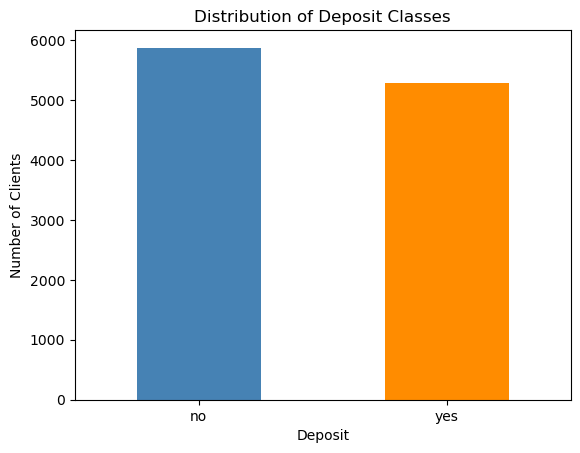

In [10]:
df["deposit"].value_counts().plot(
    kind="bar",
    color=["steelblue", "darkorange"]
)

plt.title("Distribution of Deposit Classes")
plt.xlabel("Deposit")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)
plt.show()

In [11]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.drop("deposit").tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical feature columns:")
print(categorical_columns)

Numeric columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical feature columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [12]:
for column in categorical_columns:
    print("=" * 50)
    print(f"{column}:")
    print(df[column].value_counts(dropna=False))

job:
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
marital:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
education:
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
default:
default
no     10994
yes      168
Name: count, dtype: int64
housing:
housing
no     5881
yes    5281
Name: count, dtype: int64
loan:
loan
no     9702
yes    1460
Name: count, dtype: int64
contact:
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
month:
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64
poutcome:
p

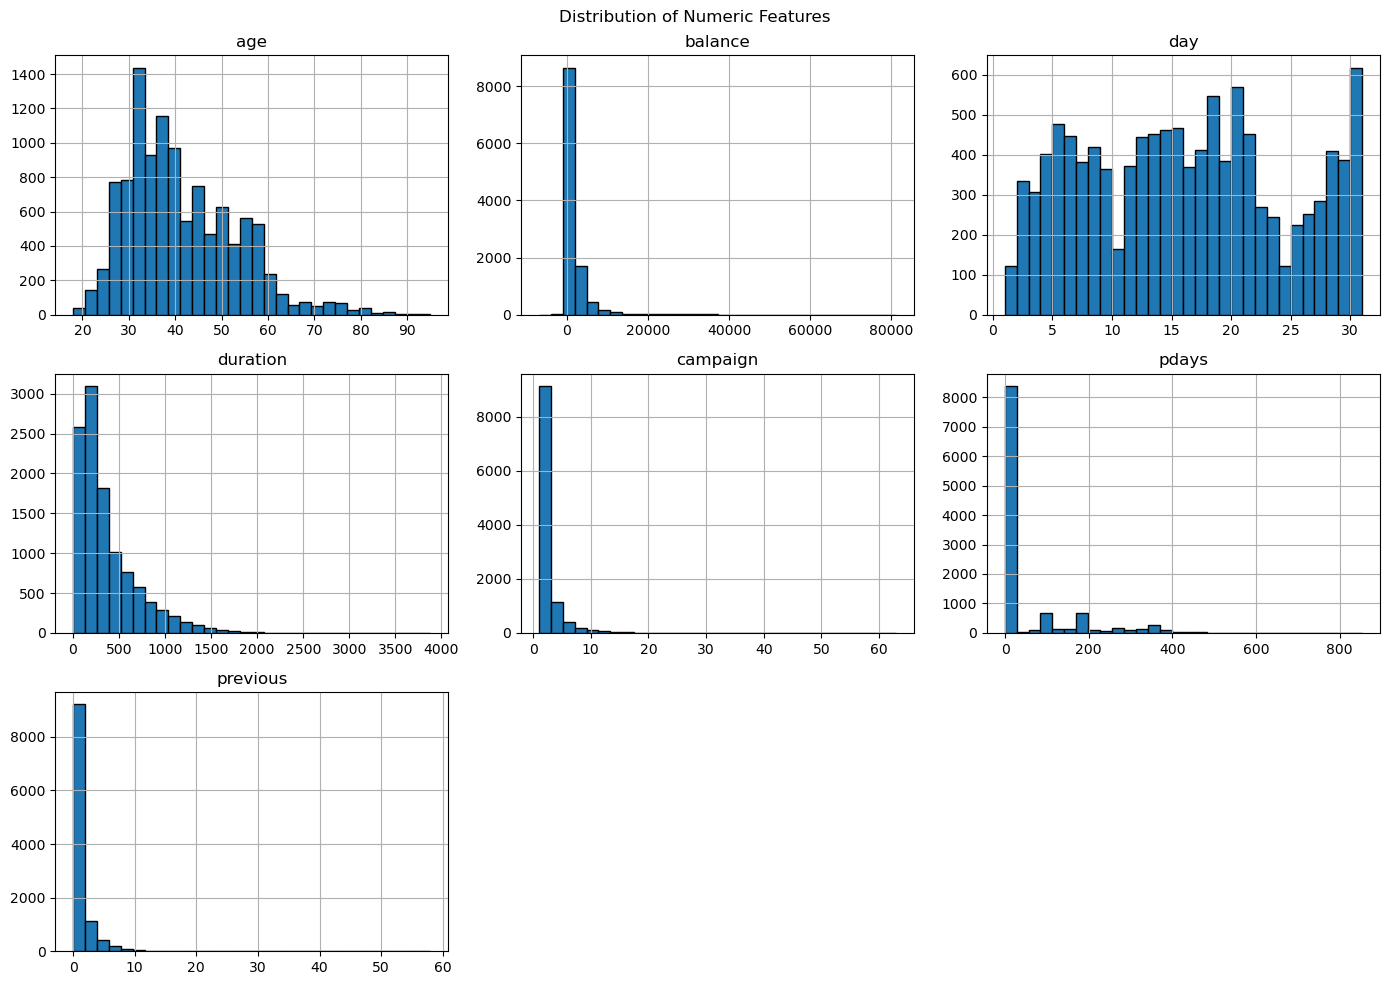

In [13]:
df[numeric_columns].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

In [14]:
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


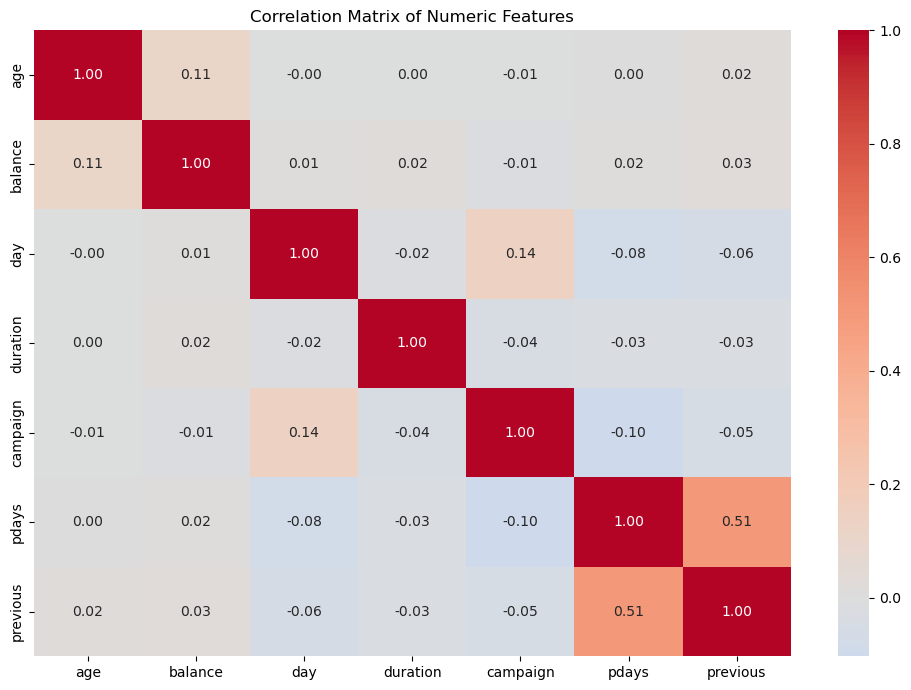

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## Data Preparation

Target-i ndahet nga veçoritë hyrëse dhe enkodohet në formë numerike. Dataset-i ndahet në 80% trajnim dhe 20% testim duke përdorur stratifikim.

In [16]:
target = "deposit"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11162, 16)
y shape: (11162,)


In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded target example:", y_encoded[:10])

Classes: ['no' 'yes']
Encoded target example: [1 1 1 1 1 1 1 1 1 1]


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8929, 16)
X_test shape: (2233, 16)
y_train shape: (8929,)
y_test shape: (2233,)


In [19]:
print("Train target distribution:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

Train target distribution:
0    52.615074
1    47.384926
Name: proportion, dtype: float64

Test target distribution:
0    52.619794
1    47.380206
Name: proportion, dtype: float64


## Preprocessing

Veçoritë numerike standardizohen me `StandardScaler`, ndërsa ato kategorike transformohen me `OneHotEncoder`. Preprocessing-u mbahet brenda pipeline-it për të shmangur data leakage.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [22]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    )
}

In [23]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_results = []

for name, model in baseline_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    baseline_results.append({
        "Model": name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1-score": cv_scores["test_f1"].mean(),
        "CV F1 Std": cv_scores["test_f1"].std()
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV F1 Std
0,Logistic Regression,0.824503,0.828474,0.794143,0.810793,0.010065
1,KNN,0.800874,0.812347,0.753962,0.781918,0.014652
2,Decision Tree,0.793930,0.784234,0.779721,0.781925,0.002197
3,Random Forest,0.850374,0.820849,0.875205,0.847138,0.008364


In [24]:
baseline_results_df.sort_values(
    by="CV F1-score",
    ascending=False
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score,CV F1 Std
3,Random Forest,0.850374,0.820849,0.875205,0.847138,0.008364
0,Logistic Regression,0.824503,0.828474,0.794143,0.810793,0.010065
2,Decision Tree,0.793930,0.784234,0.779721,0.781925,0.002197
1,KNN,0.800874,0.812347,0.753962,0.781918,0.014652


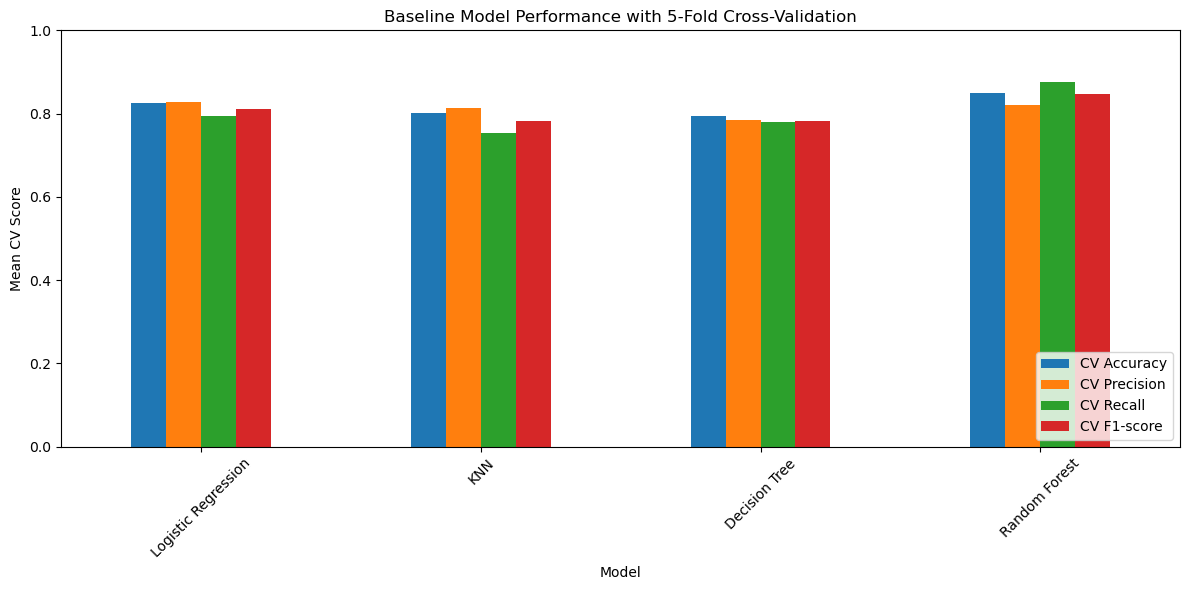

In [25]:
baseline_results_df.set_index("Model")[
    ["CV Accuracy", "CV Precision", "CV Recall", "CV F1-score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance with 5-Fold Cross-Validation")
plt.ylabel("Mean CV Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
best_baseline_model = baseline_results_df.sort_values(
    by="CV F1-score",
    ascending=False
).iloc[0]

print("Best baseline model based on cross-validation:")
best_baseline_model

Best baseline model based on cross-validation:


Model           Random Forest
CV Accuracy          0.850374
CV Precision         0.820849
CV Recall            0.875205
CV F1-score          0.847138
CV F1 Std            0.008364
Name: 3, dtype: object

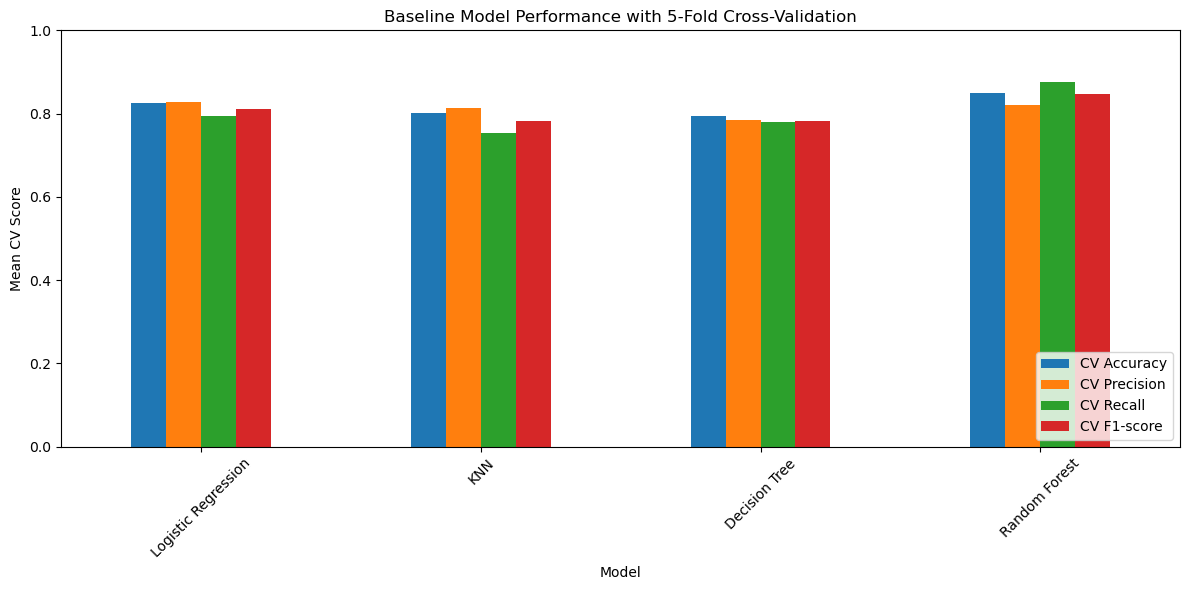

In [27]:
baseline_results_df.set_index("Model")[
    ["CV Accuracy", "CV Precision", "CV Recall", "CV F1-score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance with 5-Fold Cross-Validation")
plt.ylabel("Mean CV Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV

## Feature Selection

`SelectKBest` teston numra të ndryshëm veçorish. Zgjedhja bëhet me 5-fold cross-validation vetëm mbi train set.

In [29]:
feature_selection_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_classif)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

feature_selection_grid = GridSearchCV(
    estimator=feature_selection_pipeline,
    param_grid={
        "selector__k": [5, 10, 15, 20, 30, 40, "all"]
    },
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

feature_selection_grid.fit(X_train, y_train)

print("Best number of features:")
print(feature_selection_grid.best_params_["selector__k"])

print("Best cross-validation F1-score:")
print(feature_selection_grid.best_score_)

Best number of features:
all
Best cross-validation F1-score:
0.8107927311339077


In [30]:
feature_selection_df = pd.DataFrame({
    "Number of Features": feature_selection_grid.cv_results_[
        "param_selector__k"
    ].astype(str),
    "Mean CV F1-score": feature_selection_grid.cv_results_[
        "mean_test_score"
    ],
    "CV F1 Std": feature_selection_grid.cv_results_[
        "std_test_score"
    ]
})

feature_selection_df

,Number of Features,Mean CV F1-score,CV F1 Std
0,5,0.745280,0.006019
1,10,0.769417,0.011430
2,15,0.786989,0.007207
3,20,0.797677,0.008872
4,30,0.804281,0.007314
5,40,0.803088,0.008255
6,all,0.810793,0.010065


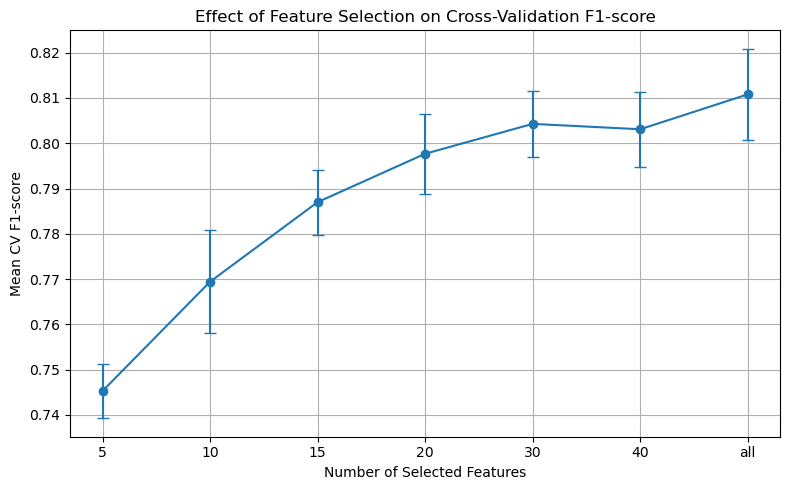

In [31]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    feature_selection_df["Number of Features"],
    feature_selection_df["Mean CV F1-score"],
    yerr=feature_selection_df["CV F1 Std"],
    marker="o",
    capsize=4
)

plt.title("Effect of Feature Selection on Cross-Validation F1-score")
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV F1-score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
best_k = feature_selection_grid.best_params_["selector__k"]
best_feature_score = feature_selection_grid.best_score_

print("Best number of selected features:", best_k)
print("Best cross-validation F1-score:", best_feature_score)


Best number of selected features: all
Best cross-validation F1-score: 0.8107927311339077


### Feature Selection Result

Rezultati më i mirë u arrit duke përdorur të gjitha veçoritë, me CV F1-score rreth 0.811. Reduktimi i veçorive nuk e përmirësoi performancën.

## Classification and Hyperparameter Tuning

Krahasohen Logistic Regression, KNN, Decision Tree dhe Random Forest. Për secilin model përdoret `GridSearchCV`, ndërsa konfigurimi më i mirë zgjidhet sipas F1-score.

In [33]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

log_reg_params = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__class_weight": [None, "balanced"]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

log_reg_grid.fit(X_train, y_train)

print("Best parameters for Logistic Regression:")
print(log_reg_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(log_reg_grid.best_score_)

Best parameters for Logistic Regression:
{'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}

Best cross-validation F1-score:
0.8172899756204159


In [34]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

knn_params = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

knn_grid.fit(X_train, y_train)

print("Best parameters for KNN:")
print(knn_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(knn_grid.best_score_)


Best parameters for KNN:
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}

Best cross-validation F1-score:
0.7949961092561025


In [35]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

dt_params = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

dt_grid.fit(X_train, y_train)

print("Best parameters for Decision Tree:")
print(dt_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(dt_grid.best_score_)

Best parameters for Decision Tree:
{'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}

Best cross-validation F1-score:
0.8215993761827678


In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE
    ))
])

rf_params = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print("Best parameters for Random Forest:")
print(rf_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(rf_grid.best_score_)


Best parameters for Random Forest:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best cross-validation F1-score:
0.85106579295044


In [37]:
tuning_summary = [
    {
        "Model": "Logistic Regression",
        "Tested Parameters": log_reg_params,
        "Best Parameters": log_reg_grid.best_params_,
        "Best CV F1-score": log_reg_grid.best_score_
    },
    {
        "Model": "KNN",
        "Tested Parameters": knn_params,
        "Best Parameters": knn_grid.best_params_,
        "Best CV F1-score": knn_grid.best_score_
    },
    {
        "Model": "Decision Tree",
        "Tested Parameters": dt_params,
        "Best Parameters": dt_grid.best_params_,
        "Best CV F1-score": dt_grid.best_score_
    },
    {
        "Model": "Random Forest",
        "Tested Parameters": rf_params,
        "Best Parameters": rf_grid.best_params_,
        "Best CV F1-score": rf_grid.best_score_
    }
]

tuning_summary_df = pd.DataFrame(tuning_summary)
tuning_summary_df


,Model,Tested Parameters,Best Parameters,Best CV F1-score
0,Logistic Regression,"{'classifier__C': [0.01, 0.1, 1, 10], 'classif...","{'classifier__C': 10, 'classifier__class_weigh...",0.817290
1,KNN,"{'classifier__n_neighbors': [3, 5, 7, 9, 11, 1...","{'classifier__metric': 'euclidean', 'classifie...",0.794996
2,Decision Tree,"{'classifier__criterion': ['gini', 'entropy'],...","{'classifier__class_weight': 'balanced', 'clas...",0.821599
3,Random Forest,"{'classifier__n_estimators': [50, 100, 200], '...","{'classifier__max_depth': None, 'classifier__m...",0.851066


In [38]:
tuned_models = {
    "Logistic Regression Tuned": log_reg_grid.best_estimator_,
    "KNN Tuned": knn_grid.best_estimator_,
    "Decision Tree Tuned": dt_grid.best_estimator_,
    "Random Forest Tuned": rf_grid.best_estimator_
}

tuned_cv_results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression Tuned",
        "Best CV F1-score": log_reg_grid.best_score_
    },
    {
        "Model": "KNN Tuned",
        "Best CV F1-score": knn_grid.best_score_
    },
    {
        "Model": "Decision Tree Tuned",
        "Best CV F1-score": dt_grid.best_score_
    },
    {
        "Model": "Random Forest Tuned",
        "Best CV F1-score": rf_grid.best_score_
    }
])

tuned_cv_results_df.sort_values(
    by="Best CV F1-score",
    ascending=False
)

,Model,Best CV F1-score
3,Random Forest Tuned,0.851066
2,Decision Tree Tuned,0.821599
0,Logistic Regression Tuned,0.817290
1,KNN Tuned,0.794996


In [39]:
baseline_f1_df = baseline_results_df[
    ["Model", "CV F1-score"]
].copy()

baseline_f1_df["Model Type"] = "Baseline"
baseline_f1_df = baseline_f1_df.rename(
    columns={"CV F1-score": "CV F1-score Comparison"}
)

tuned_f1_df = tuned_cv_results_df.copy()
tuned_f1_df["Model Type"] = "Tuned"
tuned_f1_df = tuned_f1_df.rename(
    columns={"Best CV F1-score": "CV F1-score Comparison"}
)

comparison_baseline_tuned_df = pd.concat(
    [baseline_f1_df, tuned_f1_df],
    ignore_index=True
)

comparison_baseline_tuned_df.sort_values(
    by="CV F1-score Comparison",
    ascending=False
)


,Model,CV F1-score Comparison,Model Type
7,Random Forest Tuned,0.851066,Tuned
3,Random Forest,0.847138,Baseline
6,Decision Tree Tuned,0.821599,Tuned
4,Logistic Regression Tuned,0.817290,Tuned
0,Logistic Regression,0.810793,Baseline
5,KNN Tuned,0.794996,Tuned
2,Decision Tree,0.781925,Baseline
1,KNN,0.781918,Baseline


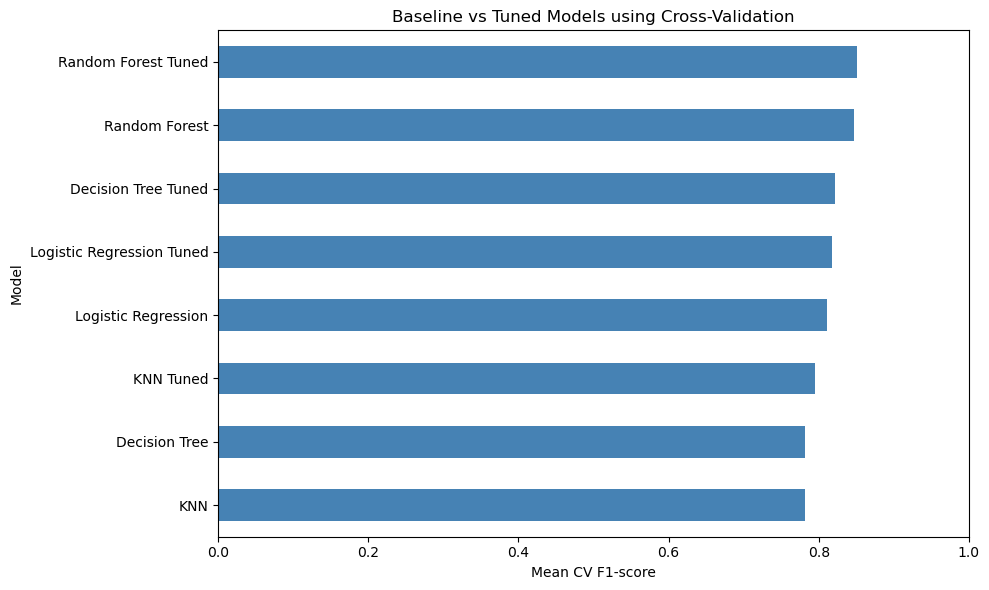

In [40]:
comparison_baseline_tuned_df.set_index("Model")[
    "CV F1-score Comparison"
].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    color="steelblue"
)

plt.title("Baseline vs Tuned Models using Cross-Validation")
plt.xlabel("Mean CV F1-score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [41]:
best_tuned_model = tuned_cv_results_df.sort_values(
    by="Best CV F1-score",
    ascending=False
).iloc[0]

print("Best tuned model based on cross-validation:")
best_tuned_model


Best tuned model based on cross-validation:


Model               Random Forest Tuned
Best CV F1-score               0.851066
Name: 3, dtype: object

In [42]:
best_tuned_name = tuned_cv_results_df.sort_values(
    by="Best CV F1-score",
    ascending=False
).iloc[0]["Model"]

best_classical_model = tuned_models[best_tuned_name]


In [43]:
print("Selected classical model:")
print(best_tuned_name)

print(
    "Cross-validation F1-score:",
    tuned_cv_results_df.loc[
        tuned_cv_results_df["Model"] == best_tuned_name,
        "Best CV F1-score"
    ].iloc[0]
)

Selected classical model:
Random Forest Tuned
Cross-validation F1-score: 0.85106579295044


In [44]:
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

## Neural Network

Testohen arkitekturat `(32,)`, `(64, 32)` dhe `(128, 64, 32)`. Gjithashtu bëhet tuning i activation function, `alpha` dhe learning rate.

In [45]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=RANDOM_STATE
    ))
])

mlp_params = {
    "classifier__hidden_layer_sizes": [
        (32,),
        (64, 32),
        (128, 64, 32)
    ],
    "classifier__activation": ["relu", "tanh"],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001]
}

In [46]:
mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

mlp_grid.fit(X_train, y_train)

print("Best Neural Network parameters:")
print(mlp_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(mlp_grid.best_score_)

Best Neural Network parameters:
{'classifier__activation': 'tanh', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (128, 64, 32), 'classifier__learning_rate_init': 0.001}

Best cross-validation F1-score:
0.8447980714709153


In [47]:
mlp_results_df = pd.DataFrame({
    "Architecture": [
        str(value)
        for value in mlp_grid.cv_results_[
            "param_classifier__hidden_layer_sizes"
        ]
    ],
    "Activation": list(
        mlp_grid.cv_results_["param_classifier__activation"]
    ),
    "Alpha": list(
        mlp_grid.cv_results_["param_classifier__alpha"]
    ),
    "Mean CV F1-score": mlp_grid.cv_results_[
        "mean_test_score"
    ],
    "CV F1 Std": mlp_grid.cv_results_[
        "std_test_score"
    ]
})

mlp_results_df.sort_values(
    by="Mean CV F1-score",
    ascending=False
)

,Architecture,Activation,Alpha,Mean CV F1-score,CV F1 Std
11,"(128, 64, 32)",tanh,0.0010,0.844798,0.007792
2,"(128, 64, 32)",relu,0.0001,0.844781,0.008091
5,"(128, 64, 32)",relu,0.0010,0.843188,0.009924
8,"(128, 64, 32)",tanh,0.0001,0.842812,0.006981
0,"(32,)",relu,0.0001,0.840537,0.009219
3,"(32,)",relu,0.0010,0.839633,0.008738
4,"(64, 32)",relu,0.0010,0.839537,0.012842
1,"(64, 32)",relu,0.0001,0.838799,0.012074
7,"(64, 32)",tanh,0.0001,0.832493,0.015662
10,"(64, 32)",tanh,0.0010,0.832398,0.015589


In [48]:
architecture_results_df = (
    mlp_results_df
    .groupby("Architecture", as_index=False)
    .agg({
        "Mean CV F1-score": "max",
        "CV F1 Std": "min"
    })
    .sort_values(
        by="Mean CV F1-score",
        ascending=False
    )
)

architecture_results_df

,Architecture,Mean CV F1-score,CV F1 Std
0,"(128, 64, 32)",0.844798,0.006981
1,"(32,)",0.840537,0.008738
2,"(64, 32)",0.839537,0.012074


In [49]:
best_nn_model = mlp_grid.best_estimator_

print("Selected Neural Network model:")
print(mlp_grid.best_params_)

print(
    "Best Neural Network cross-validation F1-score:",
    mlp_grid.best_score_
)

Selected Neural Network model:
{'classifier__activation': 'tanh', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (128, 64, 32), 'classifier__learning_rate_init': 0.001}
Best Neural Network cross-validation F1-score: 0.8447980714709153


In [50]:
architecture_results_df = mlp_results_df.loc[
    mlp_results_df.groupby("Architecture")[
        "Mean CV F1-score"
    ].idxmax()
].sort_values(
    by="Mean CV F1-score",
    ascending=False
)

architecture_results_df

,Architecture,Activation,Alpha,Mean CV F1-score,CV F1 Std
11,"(128, 64, 32)",tanh,0.0010,0.844798,0.007792
0,"(32,)",relu,0.0001,0.840537,0.009219
4,"(64, 32)",relu,0.0010,0.839537,0.012842


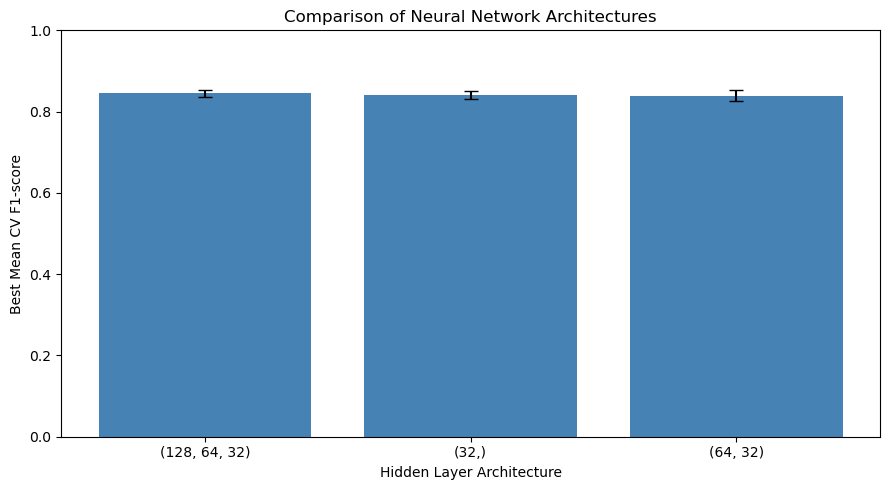

In [51]:
plt.figure(figsize=(9, 5))

plt.bar(
    architecture_results_df["Architecture"],
    architecture_results_df["Mean CV F1-score"],
    yerr=architecture_results_df["CV F1 Std"],
    capsize=5,
    color="steelblue"
)

plt.title("Comparison of Neural Network Architectures")
plt.xlabel("Hidden Layer Architecture")
plt.ylabel("Best Mean CV F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Neural Network Result

Arkitektura `(128, 64, 32)` me aktivizim `tanh` dhe `alpha=0.001` arriti rezultatin më të mirë, me CV F1-score rreth 0.845. Arkitekturat më të vogla prodhuan rezultate pak më të ulëta.

## Effect of Call Duration

Veçoria `duration` njihet vetëm pasi telefonata përfundon. Random Forest vlerësohet me dhe pa këtë veçori për të matur ndikimin e saj.

In [52]:
from sklearn.base import clone

X_train_no_duration = X_train.drop(columns=["duration"])

numeric_features_no_duration = X_train_no_duration.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_no_duration = X_train_no_duration.select_dtypes(
    include=["object"]
).columns.tolist()

preprocessor_no_duration = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_no_duration),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_no_duration
        )
    ]
)

In [53]:
rf_with_duration = clone(rf_grid.best_estimator_)

rf_without_duration = Pipeline(steps=[
    ("preprocessor", preprocessor_no_duration),
    (
        "classifier",
        clone(rf_grid.best_estimator_.named_steps["classifier"])
    )
])

duration_results = []

for name, model, features in [
    ("With duration", rf_with_duration, X_train),
    ("Without duration", rf_without_duration, X_train_no_duration)
]:
    scores = cross_validate(
        model,
        features,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    duration_results.append({
        "Feature Set": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1-score": scores["test_f1"].mean()
    })

duration_results_df = pd.DataFrame(duration_results)
duration_results_df

,Feature Set,CV Accuracy,CV Precision,CV Recall,CV F1-score
0,With duration,0.853398,0.820375,0.884189,0.851066
1,Without duration,0.732109,0.752564,0.648308,0.696241


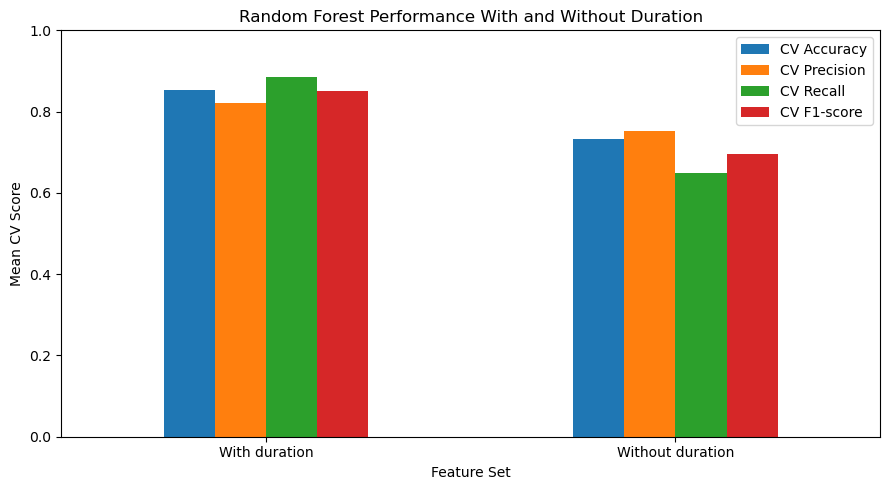

In [54]:
duration_results_df.set_index("Feature Set")[
    ["CV Accuracy", "CV Precision", "CV Recall", "CV F1-score"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Random Forest Performance With and Without Duration")
plt.ylabel("Mean CV Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Duration Result

Random Forest arriti F1-score rreth 0.851 me `duration` dhe 0.696 pa të. Kjo tregon se kohëzgjatja e telefonatës ka ndikim të madh, por nuk është e disponueshme për parashikim para përfundimit të telefonatës.

## KMeans Clustering

Target-i dhe `duration` largohen para clustering-ut. Testohen disa numra cluster-ash dhe dy metoda inicializimi, ndërsa rezultatet vlerësohen me inertia, silhouette score, ARI dhe NMI.


In [55]:
X_clustering = X.drop(columns=["duration"]).copy()

X_clustering_processed = preprocessor_no_duration.fit_transform(
    X_clustering
)

print("Original clustering data shape:", X_clustering.shape)
print("Processed clustering data shape:", X_clustering_processed.shape)

Original clustering data shape: (11162, 15)
Processed clustering data shape: (11162, 50)


In [56]:
clustering_results = []

for init_method in ["k-means++", "random"]:
    for k in [2, 3, 4, 5, 6]:
        kmeans = KMeans(
            n_clusters=k,
            init=init_method,
            random_state=RANDOM_STATE,
            n_init=10
        )

        cluster_labels = kmeans.fit_predict(
            X_clustering_processed
        )

        clustering_results.append({
            "Number of Clusters": k,
            "Initialization": init_method,
            "Inertia": kmeans.inertia_,
            "Silhouette Score": silhouette_score(
                X_clustering_processed,
                cluster_labels,
                sample_size=5000,
                random_state=RANDOM_STATE
            ),
            "Adjusted Rand Index": adjusted_rand_score(
                y_encoded,
                cluster_labels
            ),
            "Normalized Mutual Information":
                normalized_mutual_info_score(
                    y_encoded,
                    cluster_labels
                )
        })

clustering_results_df = pd.DataFrame(clustering_results)

clustering_results_df.sort_values(
    by="Silhouette Score",
    ascending=False
)

,Number of Clusters,Initialization,Inertia,Silhouette Score,Adjusted Rand Index,Normalized Mutual Information
0,2,k-means++,101874.487145,0.194447,0.047350,0.040902
5,2,random,101874.478939,0.194364,0.047508,0.041057
7,4,random,89018.684516,0.119125,0.020414,0.022715
2,4,k-means++,89018.552022,0.118960,0.020297,0.022612
3,5,k-means++,84078.062968,0.114021,0.018046,0.020839
1,3,k-means++,94925.900184,0.112891,0.026063,0.021179
6,3,random,94925.924219,0.112891,0.026125,0.021209
9,6,random,79576.570914,0.093234,0.012650,0.016352
4,6,k-means++,79576.407349,0.093190,0.012639,0.016341
8,5,random,84379.705456,0.087020,0.014910,0.018384


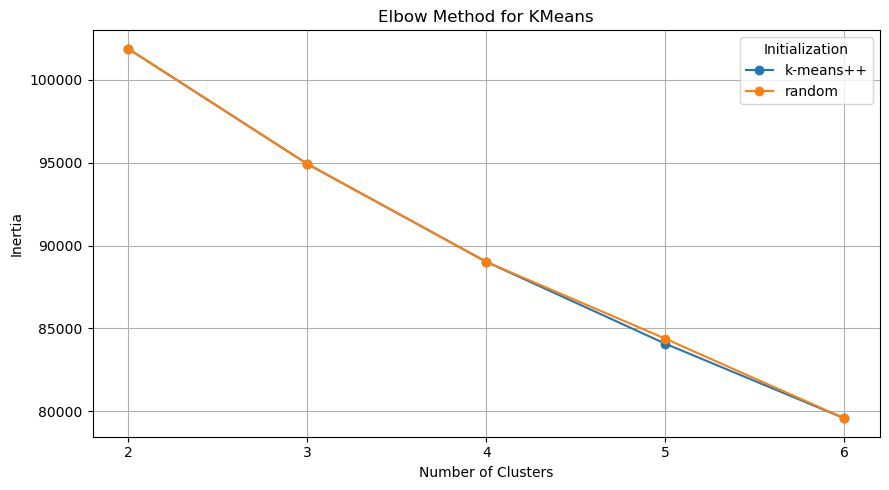

In [57]:
plt.figure(figsize=(9, 5))

for init_method in ["k-means++", "random"]:
    subset = clustering_results_df[
        clustering_results_df["Initialization"] == init_method
    ].sort_values("Number of Clusters")

    plt.plot(
        subset["Number of Clusters"],
        subset["Inertia"],
        marker="o",
        label=init_method
    )

plt.title("Elbow Method for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks([2, 3, 4, 5, 6])
plt.legend(title="Initialization")
plt.grid(True)
plt.tight_layout()
plt.show()

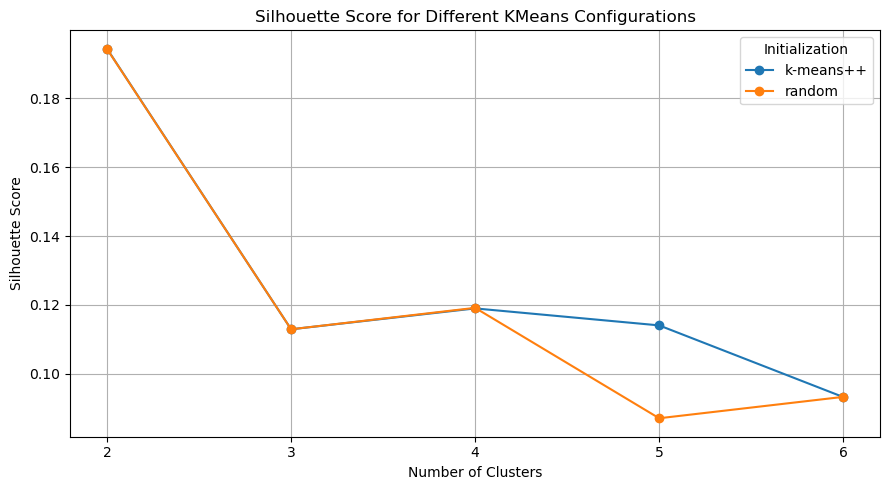

In [58]:
plt.figure(figsize=(9, 5))

for init_method in ["k-means++", "random"]:
    subset = clustering_results_df[
        clustering_results_df["Initialization"] == init_method
    ].sort_values("Number of Clusters")

    plt.plot(
        subset["Number of Clusters"],
        subset["Silhouette Score"],
        marker="o",
        label=init_method
    )

plt.title("Silhouette Score for Different KMeans Configurations")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks([2, 3, 4, 5, 6])
plt.legend(title="Initialization")
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
best_clustering_config = clustering_results_df.loc[
    clustering_results_df["Silhouette Score"].idxmax()
]

print("Best clustering configuration:")
best_clustering_config

Best clustering configuration:


Number of Clusters                           2
Initialization                       k-means++
Inertia                          101874.487145
Silhouette Score                      0.194447
Adjusted Rand Index                    0.04735
Normalized Mutual Information         0.040902
Name: 0, dtype: object

In [60]:
best_k = int(best_clustering_config["Number of Clusters"])
best_init = best_clustering_config["Initialization"]

print("Selected number of clusters:", best_k)
print("Selected initialization:", best_init)
print(
    "Best silhouette score:",
    best_clustering_config["Silhouette Score"]
)

Selected number of clusters: 2
Selected initialization: k-means++
Best silhouette score: 0.19444674994853875


In [61]:
final_kmeans = KMeans(
    n_clusters=best_k,
    init=best_init,
    random_state=RANDOM_STATE,
    n_init=10
)

final_clusters = final_kmeans.fit_predict(
    X_clustering_processed
)

print("Cluster distribution:")
print(pd.Series(final_clusters).value_counts().sort_index())

Cluster distribution:
0    2718
1    8444
Name: count, dtype: int64


In [62]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_clustering_processed
)

explained_variance = pca.explained_variance_ratio_.sum()

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total variance explained by two components:",
    explained_variance
)

Explained variance ratio:
[0.16866472 0.11786655]
Total variance explained by two components: 0.2865312687578751


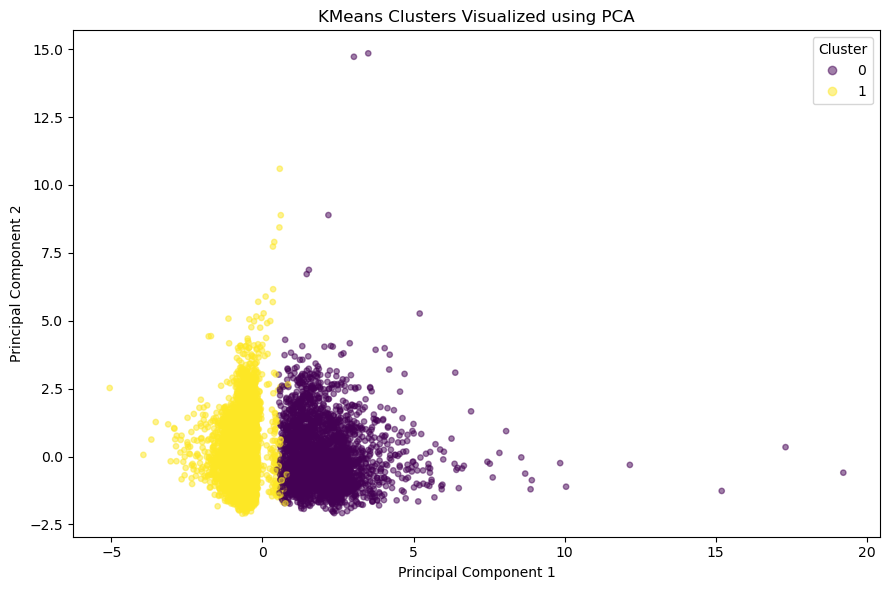

In [63]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_clusters,
    cmap="viridis",
    alpha=0.5,
    s=15
)

plt.title("KMeans Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)
plt.tight_layout()
plt.show()

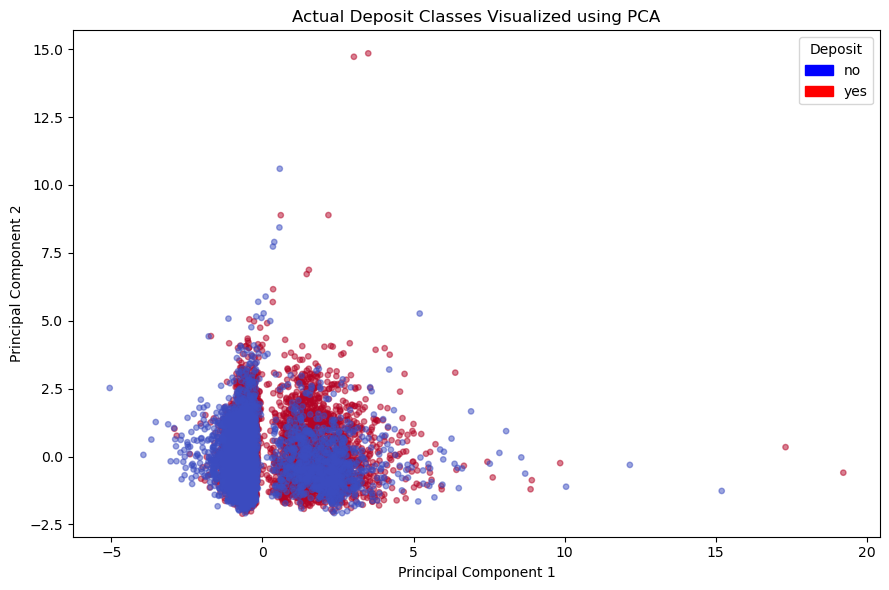

In [64]:
from matplotlib.patches import Patch

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_encoded,
    cmap="coolwarm",
    alpha=0.5,
    s=15
)

legend_elements = [
    Patch(color="blue", label="no"),
    Patch(color="red", label="yes")
]

plt.title("Actual Deposit Classes Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    handles=legend_elements,
    title="Deposit"
)
plt.tight_layout()
plt.show()

In [65]:
cluster_comparison = pd.crosstab(
    pd.Series(y.to_numpy(), name="Actual Deposit"),
    pd.Series(final_clusters, name="Cluster")
)

cluster_comparison

Cluster,0,1
Actual Deposit,,
no,893,4980
yes,1825,3464


In [66]:
final_ari = adjusted_rand_score(
    y_encoded,
    final_clusters
)

final_nmi = normalized_mutual_info_score(
    y_encoded,
    final_clusters
)

final_silhouette = silhouette_score(
    X_clustering_processed,
    final_clusters,
    sample_size=5000,
    random_state=RANDOM_STATE
)

print("Adjusted Rand Index:", final_ari)
print("Normalized Mutual Information:", final_nmi)
print("Silhouette Score:", final_silhouette)

Adjusted Rand Index: 0.0473503151176697
Normalized Mutual Information: 0.040901600554981446
Silhouette Score: 0.19444674994853875


## Final Model Evaluation

Modelet e zgjedhura me cross-validation vlerësohen vetëm një herë në test set. Përdoren accuracy, precision, recall, F1-score dhe confusion matrices.

In [67]:
final_models = {
    "Logistic Regression": log_reg_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Neural Network": mlp_grid.best_estimator_
}

final_results = []
final_predictions = {}

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    final_predictions[name] = y_pred

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, y_pred, zero_division=0
        )
    })

final_results_df = pd.DataFrame(final_results)
final_results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.828930,0.820683,0.817580,0.819129
1,KNN,0.825795,0.834166,0.789225,0.811073
2,Decision Tree,0.821764,0.776382,0.876181,0.823268
3,Random Forest,0.859382,0.825175,0.892250,0.857402
4,Neural Network,0.858039,0.817481,0.901701,0.857528


In [68]:
final_results_sorted_df = final_results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

final_results_sorted_df

,Model,Accuracy,Precision,Recall,F1-score
0,Neural Network,0.858039,0.817481,0.901701,0.857528
1,Random Forest,0.859382,0.825175,0.892250,0.857402
2,Decision Tree,0.821764,0.776382,0.876181,0.823268
3,Logistic Regression,0.828930,0.820683,0.817580,0.819129
4,KNN,0.825795,0.834166,0.789225,0.811073


In [69]:
best_final_model = final_results_sorted_df.iloc[0]

print("Best final model on the test set:")
best_final_model

Best final model on the test set:


Model        Neural Network
Accuracy           0.858039
Precision          0.817481
Recall             0.901701
F1-score           0.857528
Name: 0, dtype: object

In [70]:
for name, y_pred in final_predictions.items():
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

          no       0.84      0.84      0.84      1175
         yes       0.82      0.82      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233

KNN
              precision    recall  f1-score   support

          no       0.82      0.86      0.84      1175
         yes       0.83      0.79      0.81      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.83      0.83      2233

Decision Tree
              precision    recall  f1-score   support

          no       0.87      0.77      0.82      1175
         yes       0.78      0.88      0.82      1058

    accuracy                           0.82      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.82   

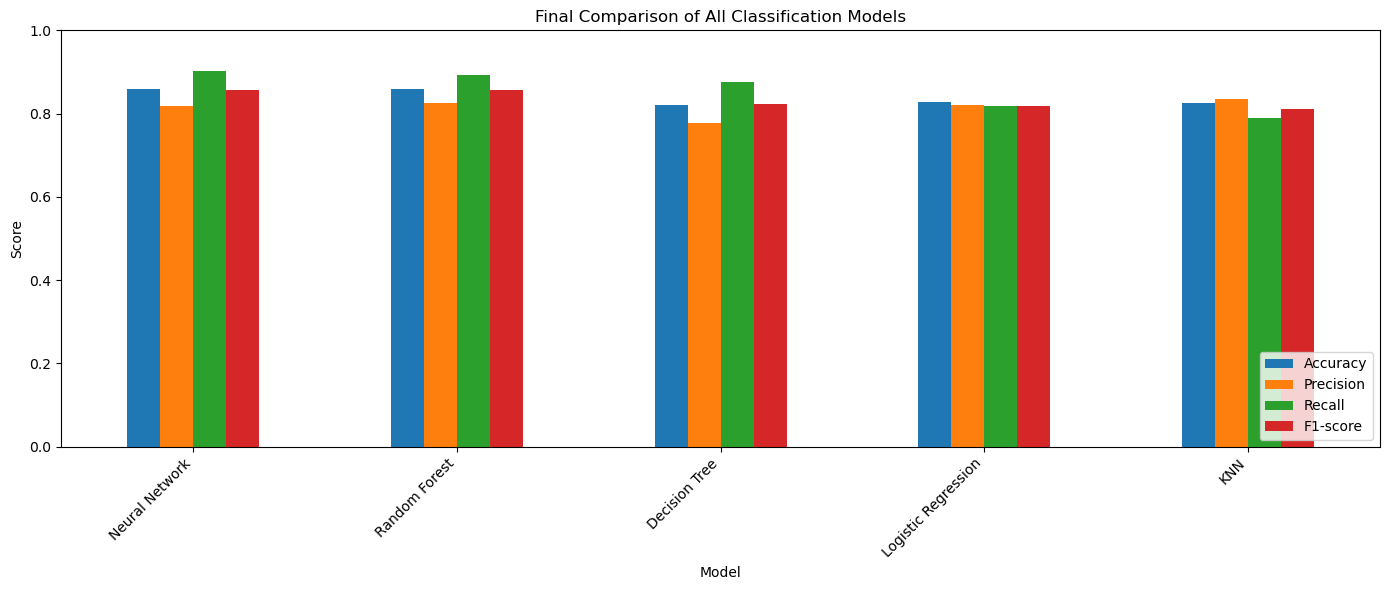

In [71]:
final_results_sorted_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Final Comparison of All Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

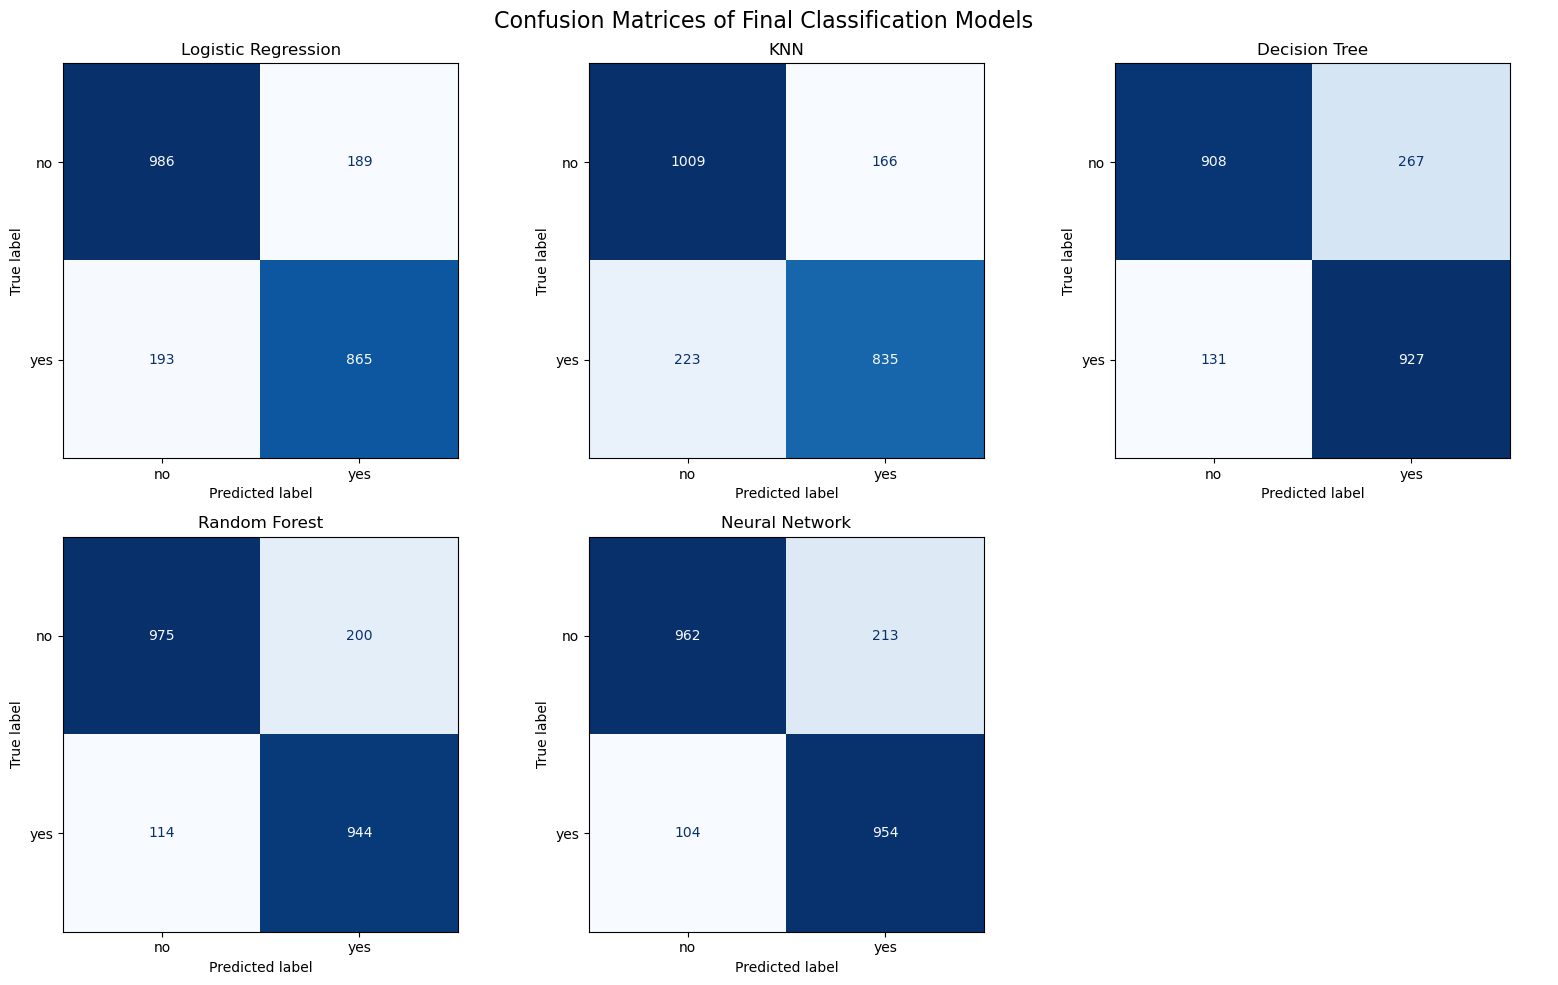

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for index, (name, y_pred) in enumerate(final_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=label_encoder.classes_,
        cmap="Blues",
        ax=axes[index],
        colorbar=False
    )

    axes[index].set_title(name)

axes[-1].axis("off")

plt.suptitle(
    "Confusion Matrices of Final Classification Models",
    fontsize=16
)
plt.tight_layout()
plt.show()

## Conclusion

Neural Network arriti F1-score më të lartë në test set, rreth 0.858, shumë afër Random Forest. Clustering-u tregoi përputhje të dobët me klasat reale, me ARI rreth 0.047 dhe silhouette score rreth 0.194.